In [1]:
import pandas as pd
import numpy as np

# load data dan format tipe data

In [2]:
df = pd.read_csv(
    './tokopedia/tokopedia_products_with_review.csv',
    # engine='pyarrow'
    )
df_ori = df.copy()

In [3]:
df_ori.columns

Index(['product_id', 'category', 'name', 'count_sold', 'discounted_price',
       'preorder', 'price', 'stock', 'gold_merchant', 'is_official',
       'is_topads', 'rating_average', 'shop_id', 'shop_location',
       'warehouse_id', 'product_url', 'review_id', 'variant_name', 'message',
       'review_rating', 'review_time', 'review_timestamp', 'review_response',
       'review_like', 'bad_rating_reason'],
      dtype='object')

In [4]:
df_ori['is_topads'].unique()

array([False])

In [5]:
df_ori['price']

0       108500
1        33000
2         9300
3        59400
4        21700
         ...  
5548     31850
5549      5348
5550     15500
5551    143301
5552     30450
Name: price, Length: 5553, dtype: int64

In [6]:
df_ori['discounted_price']

0            NaN
1            NaN
2            NaN
3       128600.0
4        32300.0
          ...   
5548         NaN
5549         NaN
5550         NaN
5551         NaN
5552         NaN
Name: discounted_price, Length: 5553, dtype: float64

In [7]:
df_ori.loc[df_ori['count_sold'].isna()].shape

(810, 25)

```mermaid
graph LR
    START([<b>Start</b>]) --> S1[1. Data Ingestion]
    S1 --> S2[2. Dropping Constants]
    S2 --> S3[3. Unnesting Layers]
    S3 --> S4[4. Casting]
    
    %% Koneksi ke tahap berikutnya
    S4 --> NEXT((<b>Next</b>))
    
    %% Styling
    style START fill:#f9f9f9,stroke:#333
    style NEXT fill:#e1e1ff,stroke:#7b7bff
```

```mermaid
graph LR
    PREV((<b>Next</b>)) --> S5[5. Imputation]
    S5 --> S6[6. Text Normalization]
    S6 --> S7[7. Final Export]
    
    S7 --> FINISH([<b>End</b>])
    
    %% Styling
    style PREV fill:#e1e1ff,stroke:#7b7bff
    style FINISH fill:#f9f9f9,stroke:#333
```

## ubah kolom list-like yang masih dalam bentuk text ke format list

In [8]:
col = ['review_id','review_rating','variant_name','message','review_time','review_timestamp','review_response','review_like','bad_rating_reason']

In [9]:
for c in col:
    df[c] = df[c].apply(lambda x: x[1:-1].split(', ') if isinstance(x, str) else x)

### cek panjang list (harus sama semua)

di masing2 kolom yang akan kita cek, isinya list di tiap barisnya, yang panjang masing-masing list bisa berbeda2, dengan asumsi masing-masing kolom dengan list memiliki panjang yang sama di tiap baris, maka ukuran yang masuk akal adalah menghitung rata-rata panjang list di tiap kolom, jika panjang tiapb baris dari list di tiap kolom sama, maka harusnya nilai rata-ratanya juga sama.

In [10]:
for c in col:
    print(c,df[c].apply(lambda x:len(x)).min(),df[c].apply(lambda x:len(x)).max(),df[c].apply(lambda x:len(x)).mean())

review_id 1 9757 242.74716369529983
review_rating 1 9757 242.74716369529983
variant_name 1 9757 242.77723752926346
message 1 14569 352.9576805330452
review_time 1 9757 242.74716369529983
review_timestamp 1 9757 242.74716369529983
review_response 1 15659 280.01170538447684
review_like 1 9757 242.74716369529983
bad_rating_reason 1 9766 243.8046101206555


yang berbeda adalah kolom message, review message, bad rating response dan variant_name, akan ditelusuri variant_name, message, review message, bad rating response

In [11]:
df['variant_name'] = df_ori['variant_name'].apply(lambda x: x[2:-2].split("', '")).apply(lambda x:len(x)).mean()

In [12]:
df['message'][0]

["'goodboy'",
 "'Produk telah diterima dalam keadaan baik dan sesuai deskripsi.'",
 "'respon penjual baik dan cepat ,kiriman barang aman sampai tujuan'",
 "'Bagus dan rapi presisi'",
 "'Barang sesuai deskripsi pengiriman cepat toko recomded puas beli disini'",
 "'ini kedua kali nya akhirnya saya beli.. krn yg pertama penjual salah kirim warna pdhal di chat sdh 2x sy bilang ingin wrn putih dan 2x pula penjual jwb iya.. sampai tempat ternyata penjual kirim wrn krem",
 'dan kl komplain hrs kirim barang salah ke penjual kembali',
 'sdgkan barang ada di kantor',
 "sungguh menyusah kan. akhirnya keputusan sy tdk komplen melainkan beli lg sesuai wrn. utk penjual harap lbh teliti lg dlm membaca dari pembeli !'",
 "'besi untuk dipasang ke dinding tidak di amplas dan cat halus. Kayu blok tik tempat besi dimasukkan sangat kasar dan rapuh.'",
 "'Bagus'",
 "'pengiriman cepat",
 "respon seller bagus'",
 "'cakep",
 'kayu nya tebel dan kokoh',
 "thanks'",
 "'halus potongan rapi sekali.tebal..bagus sem

di value ke 6 dari list pertama dari message telihat bahwa commnet tesb terpotong dan sambungannya adalah comment di value berikut dari list tsb, maka akan dilakukan pemisahan dari string ke list yang lebih spesifik untuk message dan juga review response

In [13]:
for c in ['message','review_response','bad_rating_reason','variant_name']:
    df[c] = df_ori[c].apply(lambda x: x[2:-2].split("', '"))
    print(c, df_ori[c].apply(lambda x: x[2:-2].split("', '")).apply(lambda x: len(x)).mean())

message 242.73725913920404
review_response 242.39312083558437
bad_rating_reason 242.74716369529983
variant_name 242.74158112731857


kolom bad_rating_reason nilai rata-ratanya sudah sama dengan kolom review_id dll, kolom message dan kolom review_response nilai rata-ratanya lebih kecil, maka bisa jadi ada comment dan juga review_response yang harusnya menjadi list terpisah masih jadi satu. kolom variant_name tidak akan diikut sertakan

In [14]:
df['review_response'][282]

['Terima kasih telah berbelanja di IKEA Indonesia. Bagikan link toko kami https://www.tokopedia.com/ikea-indonesia kepada teman-teman Anda dan favoritkan Toko kami untuk terus update mengenai stok dan produk terbaru',
 'Terima kasih telah berbelanja di IKEA Indonesia. Bagikan link toko kami https://www.tokopedia.com/ikea-indonesia kepada teman-teman Anda dan favoritkan Toko kami untuk terus update mengenai stok dan produk terbaru',
 '',
 'Terima kasih telah berbelanja di IKEA Indonesia. Bagikan link toko kami https://www.tokopedia.com/ikea-indonesia kepada teman-teman Anda dan favoritkan Toko kami untuk terus update mengenai stok dan produk terbaru',
 'Terima kasih telah berbelanja di IKEA Indonesia. Bagikan link toko kami https://www.tokopedia.com/ikea-indonesia kepada teman-teman Anda dan favoritkan Toko kami untuk terus update mengenai stok dan produk terbaru',
 'Terima kasih telah berbelanja di IKEA Indonesia. Bagikan link toko kami https://www.tokopedia.com/ikea-indonesia kepada t

In [15]:
skip_comment1 = 'https://www.tokopedia.com/ikea-indonesia'
skip_comment2 = 'https://www.tokopedia.com/ikeaindonesia'
[v for v in [v for v in df['review_response'][282] if skip_comment1 not in v]if skip_comment2 not in v]

['',
 '',
 '',
 '',
 'Hej Kak! Terima kasih telah berbelanja di Tokopedia IKEA Indonesia. Mohon maaf atas ketidaknyamanan nya. Apabila terdapat keluhan atau kendala pada pesanan Kakak, saat ini Kakak dapat menghubungi kami melalui chat Tokopedia atau layanan Whatsapp. Nantinya terkait keluhan atau kendala pada pesanan Kakak akan dibantu oleh tim terkait kami. Terima kasih. ~ Leona',
 'Hej Kak! Terima kasih telah berbelanja di Tokopedia IKEA Indonesia. Mohon maaf atas ketidaknyamanan nya. Apabila terdapat keluhan atau kendala pada pesanan Kakak, saat ini Kakak dapat menghubungi kami melalui chat Tokopedia atau layanan Whatsapp. Nantinya terkait keluhan atau kendala pada pesanan Kakak akan dibantu oleh tim terkait kami. Terima kasih. :) -Brayen',
 'Hej Kak! Terima kasih telah berbelanja di Tokopedia IKEA Indonesia. Mohon maaf atas ketidaknyamanan nya. Apabila terdapat keluhan atau kendala pada pesanan Kakak, saat ini Kakak dapat menghubungi kami melalui chat Tokopedia atau layanan Whatsa

In [16]:
filter_1 = df['review_response'].apply(lambda x: len(x))!= df['review_id'].apply(lambda x: len(x))
filter_2 = df['message'].apply(lambda x: len(x))!= df['review_id'].apply(lambda x: len(x))

df.loc[
    filter_1|filter_2
    ].apply(lambda x:(len(x['review_id']),len(x['message']),len(x['review_response'])),axis=1)

14         (787, 785, 787)
83      (9187, 9181, 9187)
282        (180, 180, 178)
305     (2208, 2204, 2208)
306     (9757, 9755, 9757)
               ...        
5209          (51, 51, 38)
5210          (53, 53, 35)
5211          (55, 55, 29)
5229    (7952, 7952, 7594)
5450       (330, 328, 330)
Length: 63, dtype: object

setelah dilihat, sepertinya tidak ada value yang harus terbagi menjadi beberapa comment, kemungkinan ada pesan yang hilang untuk beberapa produk, 19 produk yang commentnya tidak lengkap (comment $\lt$ review_id), 45 produk yang "review_response"nya tidak lengkap dan gabungan dari keduanya adalah 63 produk. selanjutnya akan diisi dengan comment kosong untuk comment dan review_response yang panjang listnya $\lt$ review_id

In [17]:
df['message'] = df.apply(
    lambda x: x['message'] if len(x['message'])==len(x['review_id']) else x['message'] + ['']*(len(x['review_id'])-len(x['message'])),
    axis=1)

df['review_response'] = df.apply(
    lambda x: x['review_response'] if len(x['review_response'])==len(x['review_id']) else x['review_response'] + ['']*(len(x['review_id'])-len(x['review_response'])),
    axis=1)

## cek dimensi list di tiap kolom, untuk memastikan dimensinya sama sebelum melakukan flatten/explode

In [18]:
list_like_col = [
    'review_id','review_rating',#'variant_name',
    'message','review_time','review_timestamp',
    'review_response','review_like','bad_rating_reason']

In [19]:
for col in list_like_col:
    print()
    print(col,df[col].apply(lambda x:len(x)).mean())


review_id 242.74716369529983

review_rating 242.74716369529983

message 242.74716369529983

review_time 242.74716369529983

review_timestamp 242.74716369529983

review_response 242.74716369529983

review_like 242.74716369529983

bad_rating_reason 242.74716369529983


In [20]:
# list_len = df['review_id'].apply(lambda x:len(x)).to_list()

## samakan dimensi list yang berbeda (`messsage`, `review_response` & `bad_rating_reason`)

In [21]:
# df['message_new'] = df[['review_id','message']].apply(lambda x: x['message'][:len(x['review_id'])],axis=1)
# df['review_response_new'] = df[['review_id','review_response']].apply(lambda x: x['review_response'][:len(x['review_id'])],axis=1)
# df['bad_rating_reason_new'] = df[['review_id','bad_rating_reason']].apply(lambda x: x['bad_rating_reason'][:len(x['review_id'])],axis=1)

## pisah kategori

In [22]:
df['category_1'] = df['category'].apply(lambda x: x.split('|')[0])
df['category_2'] = df['category'].apply(lambda x: x.split('|')[1])

In [23]:
# list_col = list(df.columns)

In [24]:
list_col = [
    'product_id','category','category_1','category_2','name','count_sold',
    'discounted_price','preorder','price','stock',
    'gold_merchant','is_official','is_topads','rating_average',
    'shop_id','shop_location','warehouse_id',
    'product_url','review_id', #'variant_name',
    'message','review_rating','review_time',
    'review_timestamp','review_response','review_like',
    'bad_rating_reason']

In [25]:
df_new = df[list_col].copy()

In [26]:
df_new['message'][0]

['goodboy',
 'Produk telah diterima dalam keadaan baik dan sesuai deskripsi.',
 'respon penjual baik dan cepat ,kiriman barang aman sampai tujuan',
 'Bagus dan rapi presisi',
 'Barang sesuai deskripsi pengiriman cepat toko recomded puas beli disini',
 'ini kedua kali nya akhirnya saya beli.. krn yg pertama penjual salah kirim warna pdhal di chat sdh 2x sy bilang ingin wrn putih dan 2x pula penjual jwb iya.. sampai tempat ternyata penjual kirim wrn krem, dan kl komplain hrs kirim barang salah ke penjual kembali, sdgkan barang ada di kantor, sungguh menyusah kan. akhirnya keputusan sy tdk komplen melainkan beli lg sesuai wrn. utk penjual harap lbh teliti lg dlm membaca dari pembeli !',
 'besi untuk dipasang ke dinding tidak di amplas dan cat halus. Kayu blok tik tempat besi dimasukkan sangat kasar dan rapuh.',
 'Bagus',
 'pengiriman cepat, respon seller bagus',
 'cakep, kayu nya tebel dan kokoh, thanks',
 'halus potongan rapi sekali.tebal..bagus semua.puas deh.pertahankan gan',
 'kualita

In [27]:
col = ['review_id','review_rating','message','review_time','review_timestamp','review_response','review_like','bad_rating_reason']

In [28]:
df_new = df_new.loc[df_new['review_id'].apply(lambda x:len(x))!=0].copy()

## hilangkan duplikat produk

In [29]:
df_new = df_new.loc[~df_new['product_id'].duplicated()].copy()

## flatten/explode dataframe

In [30]:
df_new['review_id'].apply(lambda x: len([v for v in x if v==''])).sum() # ada review_id yang kosong/empty, ini harus dihilangkan jika mau digunakan reviewnya

np.int64(1327)

In [31]:
df_new_explode = df_new.explode(list_like_col).copy()

In [32]:
df_new_explode.loc[df_new_explode['review_id']==""].shape[0],df_new_explode.loc[df_new_explode['review_time']==""].shape[0]

(1327, 1327)

In [33]:
df_new_explode = df_new_explode.loc[df_new_explode['review_id']!=""].copy()  # hilangkan review_id yang kosong

In [34]:
df_new_explode.shape[0]

1228885

## format tipe data waktu/datetime (`review_time`)

In [35]:
from datetime import datetime, timezone, timedelta

In [36]:
df_new_explode['review_time'] = df_new_explode['review_time'].apply(
    lambda ts:datetime.fromtimestamp(int(float(ts.strip().replace("'","")))).astimezone(timezone(timedelta(hours=7))).strftime("%Y-%m-%d")
    )

## save the data

In [ ]:
df_new_explode.to_csv('tokopedia-flatten.csv')

# Explore

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [38]:
len(df_new_explode['category_1'].unique()),df_new_explode['category_1'].unique()

(22,
 array(['rumah_tangga', 'kamera', 'buku', 'dapur', 'elektronik',
        'fashion_anak', 'fashion_muslim', 'fashion_pria', 'film_musik',
        'gaming', 'handphone_tablet', 'ibu_bayi', 'kecantikan',
        'kesehatan', 'komputer_laptop', '', 'makanan_minuman',
        'office_stationery', 'olahraga', 'otomotif', 'perawatan_hewan',
        'perawatan_tubuh'], dtype=object))

In [39]:
dict_freq = {
    "D": "hari",
    "W": "minggu",
    "M": "bulan",
    "ME": "bulan",
    "YE": "tahun"
}

freq = "YE"

## Jumlah Review sepanjang waktu

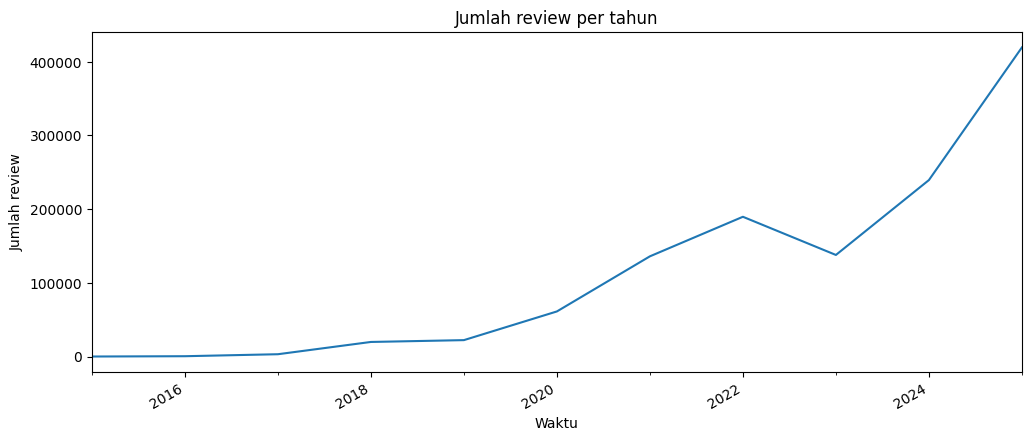

In [40]:
df = df_new_explode.copy()
df["review_time"] = pd.to_datetime(df["review_time"], errors="coerce")


n_review = (df.dropna(subset=["review_time"])
              .set_index("review_time")
              .resample(freq)
              .size())

ax = n_review.plot(figsize=(12,5))
# ax.xaxis.set_major_locator(mdates.AutoDateLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()
ax.set_xlabel("Waktu")
ax.set_ylabel("Jumlah review")
ax.set_title(f"Jumlah review per {dict_freq[freq]}")
plt.show()

## Total Review tiap minggu sepanjang waktu

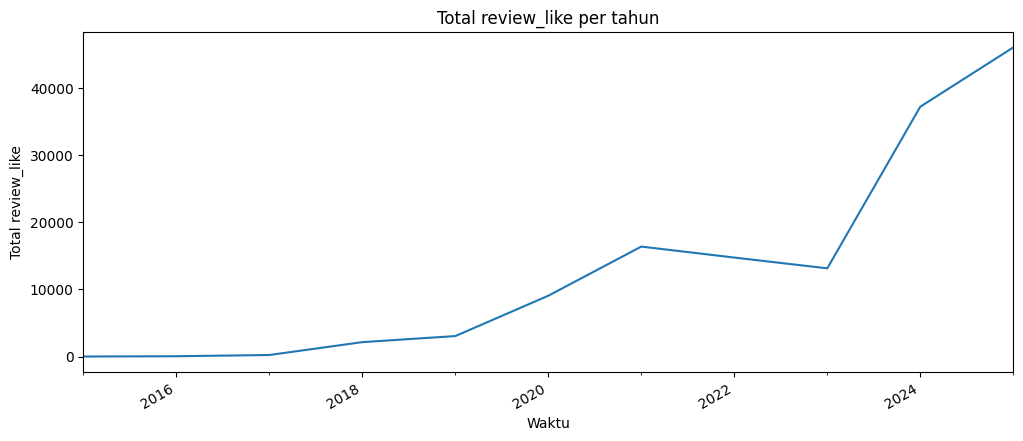

In [41]:
df = df_new_explode.copy()

# 1) Pastikan datetime
df["review_time"] = pd.to_datetime(df["review_time"], errors="coerce")  # :contentReference[oaicite:3]{index=3}
df["review_like"] = pd.to_numeric(df["review_like"], errors="coerce").fillna(0)

df = df.dropna(subset=["review_time"]).sort_values("review_time")


# 2) Agregasi total like per periode (pilih: 'D' harian, 'W' mingguan, 'M' bulanan)
freq = "YE"
ts_like = (df.set_index("review_time")["review_like"]
             .resample(freq)
             .sum())  # :contentReference[oaicite:4]{index=4}

# 3) Plot
ax = ts_like.plot(kind="line", figsize=(12,5))

# ax.xaxis.set_major_locator(mdates.AutoDateLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()

ax.set_xlabel("Waktu")
ax.set_ylabel("Total review_like")
ax.set_title(f"Total review_like per {dict_freq[freq]}")
plt.show()

## jumlah review sepanjang waktu berdasarkan kategori

/tmp/ipykernel_244998/1786201552.py:9: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .size()


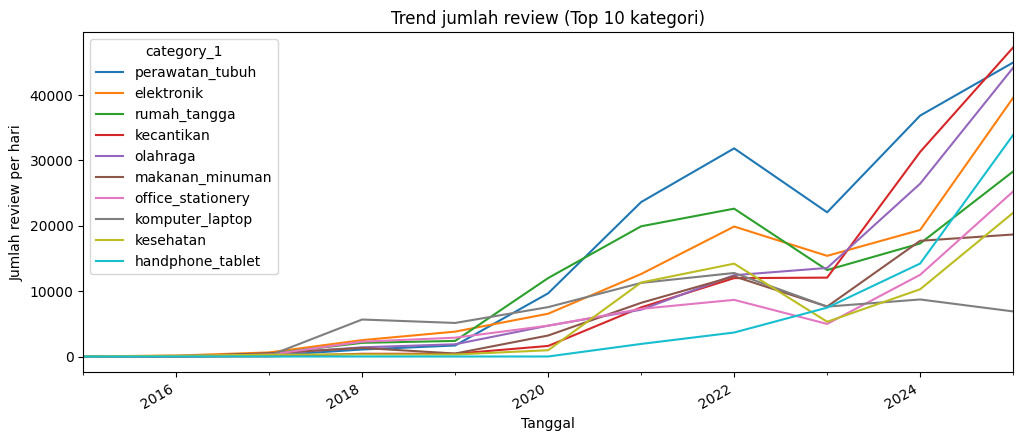

In [42]:
df = df_new_explode.copy()
df["review_time"] = pd.to_datetime(df["review_time"])
df = df.dropna(subset=["review_time", "category_1"])

# Hitung jumlah review per hari per kategori
daily = (df.set_index("review_time")
           .groupby("category_1")
           .resample(freq)
           .size()
           .unstack("category_1")
           .fillna(0))

# Ambil Top-N kategori berdasarkan total review
top_n = 10
top_cats = daily.sum().sort_values(ascending=False).head(top_n).index

ax = daily[top_cats].plot(kind="line", figsize=(12,5))
# ax.xaxis.set_major_locator(mdates.AutoDateLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gcf().autofmt_xdate()
ax.set_xlabel("Tanggal")
ax.set_ylabel("Jumlah review per hari")
ax.set_title(f"Trend jumlah review (Top {top_n} kategori)")
plt.show()

### Interpretasi

Berdasarkan tiga visualisasi di atas (tren jumlah review, tren `review_like`, dan tren review per kategori), pola umumnya menunjukkan akselerasi aktivitas pada 2020-2022 lalu melambat pada 2023. Pola ini konsisten dengan konteks pasar. selama periode pandemi, adopsi belanja online meningkat kuat, sedangkan pada 2023 terjadi normalisasi perilaku belanja dan kompetisi antar e-commerce yang lebih ketat. Penurunan indikator review Tokopedia pada 2023 juga relevan dengan berbagai pemberitaan tentang melemahnya performa/traffic Tokopedia pada periode tersebut. Di sisi lain, TikTok Shop mulai agresif dan semakin populer di Indonesia sejak 2022 melalui model social commerce berbasis konten/live shopping, sehingga sebagian trafik dan transaksi berpotensi terdistribusi dari marketplace konvensional ke kanal social commerce. Dinamika 2023 juga penting: setelah penutupan layanan social commerce TikTok Shop pada September-Oktober 2023 akibat perubahan regulasi, TikTok dan Tokopedia kemudian mengumumkan transaksi strategis pada Desember 2023 (integrasi bisnis TikTok Shop Indonesia ke entitas Tokopedia). Artinya, penurunan tren aktivitas Tokopedia pada 2023 dapat dibaca bukan hanya sebagai penurunan pembelian, tetapi juga sebagai fase transisi struktur pasar e-commerce Indonesia sebelum konsolidasi/merger TikTok-Tokopedia.

Referensi berita/data pendukung:
1. GoTo FY 2023 Results (19 Maret 2024): https://www.gotocompany.com/en/news/press/goto-group-turns-adjusted-ebitda-positive-surpassing-full-year-guidance-as-company-reports-2023-fourth-quarter-and-full-year-results
2. Databoks - 5 E-Commerce dengan Pengunjung Terbanyak Sepanjang 2023 (15 Januari 2024): https://databoks.katadata.co.id/en/infographics/2024/01/15/5-e-commerce-dengan-pengunjung-terbanyak-sepanjang-2023
3. Google Indonesia - e-Conomy SEA 2022 (7 November 2022): https://blog.google/intl/id-id/company-news/outreach-initiatives/2022_11_economy-sea-2022-indonesia/
4. Kementerian Perdagangan RI - TikTok patuhi Permendag 31/2023 (4 Oktober 2023): https://www.kemendag.go.id/berita/siaran-pers/mendag-zulkifli-hasan-dukung-tiktok-patuhi-permendag-31-tahun-2023
5. AP News - TikTok Shop hentikan retail business di Indonesia (4 Oktober 2023): https://apnews.com/article/62e5ef9f366d8cfd4a94427393bb5aba
6. TikTok Newsroom - Kemitraan strategis GoTo dan TikTok (11 Desember 2023): https://newsroom.tiktok.com/in-id/goto-dan-tiktok-sepakati-kemitraan-strategis-e-commerce-untuk-mendorong-kemajuan-umkm-indonesia/
7. CNBC - TikTok invest US$1.5 miliar di unit e-commerce GoTo (10-11 Desember 2023): https://www.cnbc.com/2023/12/11/tiktok-to-invest-1point5-billion-in-gotos-indonesia-e-commerce-business.html
8. Momentum Works - laporan e-commerce Asia Tenggara 2023 (1 Juli 2024): https://thelowdown.momentum.asia/press-release-southeast-asia-ecommerce-achieves-us114-6-billion-gmv-in-2023-momentum-works/

## Jumlah review per hari sepanjang waktu by category

/tmp/ipykernel_244998/607725757.py:11: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .size()


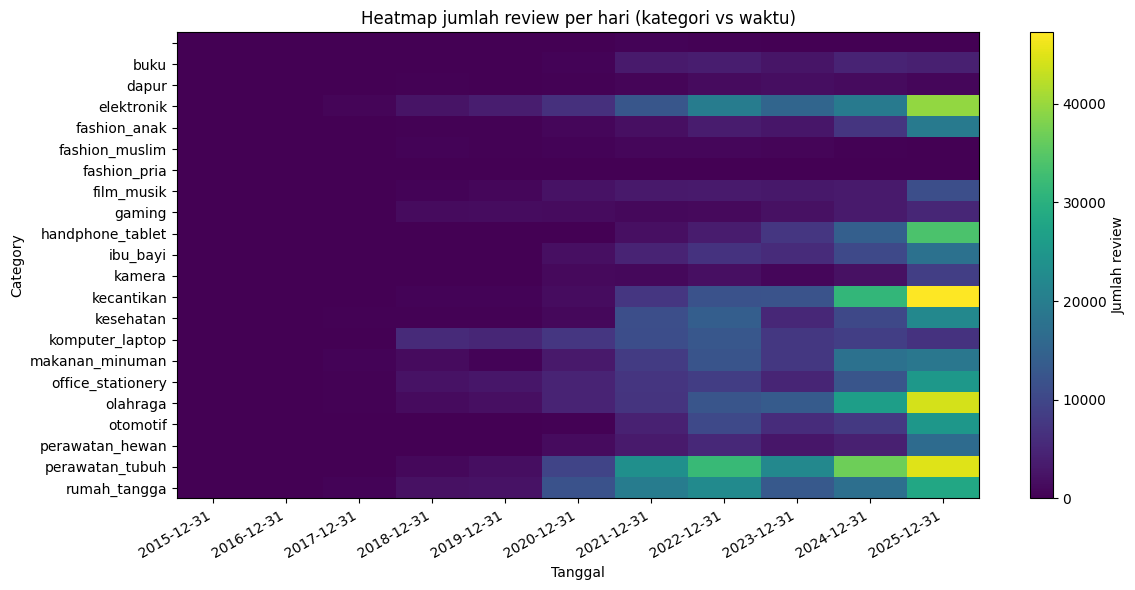

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = df_new_explode.copy()
df["review_time"] = pd.to_datetime(df["review_time"])
df = df.dropna(subset=["review_time", "category_1"])

daily = (df.set_index("review_time")
           .groupby("category_1")
           .resample(freq)
           .size()
           .unstack("category_1")
           .fillna(0))

# heatmap: baris=category, kolom=tanggal
mat = daily.T.values
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(mat, aspect="auto", interpolation="nearest")

ax.set_yticks(np.arange(len(daily.columns)))
ax.set_yticklabels(daily.columns)

# label X secukupnya biar tidak penuh
step = max(1, len(daily.index)//10)
xticks = np.arange(0, len(daily.index), step)
ax.set_xticks(xticks)
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in daily.index[::step]], rotation=30, ha="right")

ax.set_title("Heatmap jumlah review per hari (kategori vs waktu)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Category")
fig.colorbar(im, ax=ax, label="Jumlah review")
plt.tight_layout()
plt.show()

## rating mingguan sepanjang waktu

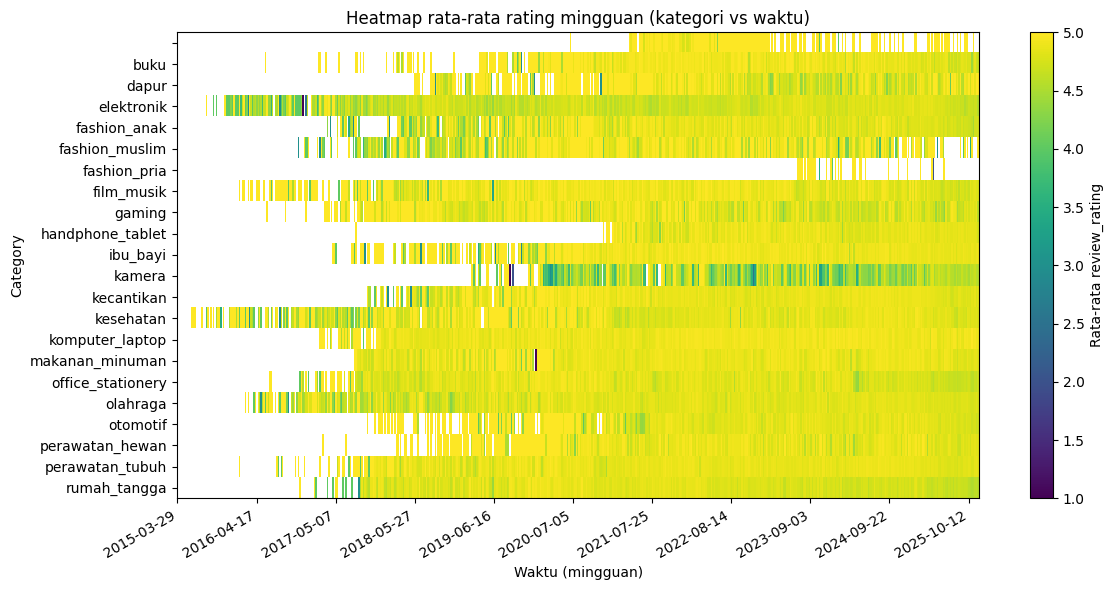

In [44]:
df = df_new_explode.copy()
df["review_time"] = pd.to_datetime(df["review_time"], errors="coerce")
df["review_rating"] = pd.to_numeric(df["review_rating"], errors="coerce")
df = df.dropna(subset=["review_time", "review_rating", "category_1"])

weekly_mean = (df.set_index("review_time")
                 .groupby("category_1")["review_rating"]
                 .resample("W")
                 .mean()
                 .unstack("category_1"))

# Ubah jadi (kategori x waktu)
mat = weekly_mean.T.values

fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(mat, aspect="auto", interpolation="nearest")

ax.set_yticks(np.arange(len(weekly_mean.columns)))
ax.set_yticklabels(weekly_mean.columns)

# label X secukupnya
idx = weekly_mean.index
step = max(1, len(idx)//10)
xticks = np.arange(0, len(idx), step)
ax.set_xticks(xticks)
ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in idx[::step]], rotation=30, ha="right")

ax.set_title("Heatmap rata-rata rating mingguan (kategori vs waktu)")
ax.set_xlabel("Waktu (mingguan)")
ax.set_ylabel("Category")
fig.colorbar(im, ax=ax, label="Rata-rata review_rating")
plt.tight_layout()
plt.show()

In [ ]:
# freq = "YE"
# g = df.set_index("review_time").resample(freq).agg(
#     total_like=("review_like", "sum"),
#     n_review=("review_like", "size"),
# )
# g["avg_like_per_review"] = g["total_like"] / g["n_review"]

# ax = g["avg_like_per_review"].plot(kind="line", figsize=(12,5))
# # ax.xaxis.set_major_locator(mdates.AutoDateLocator())
# # ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# plt.gcf().autofmt_xdate()

# ax.set_xlabel("Waktu")
# ax.set_ylabel("Rata-rata like per review")
# ax.set_title(f"Avg review_like per review (per {freq})")
# plt.show()

# Research Question

## Sales Official Store dan Gold Merchant

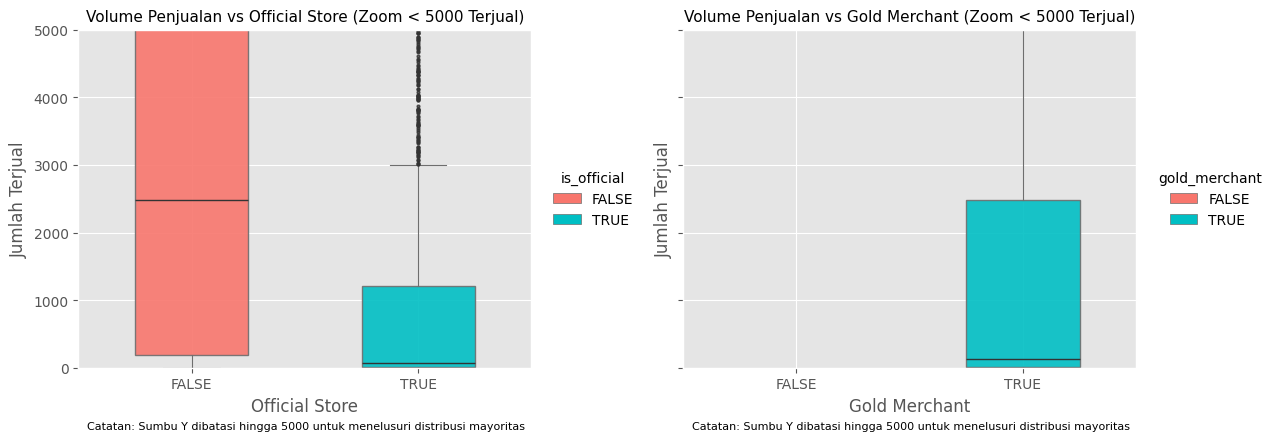

In [60]:
from matplotlib.patches import Patch

df_store_sales = (
    df_new_explode[["product_id", "count_sold", "is_official", "gold_merchant"]]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

def to_flag(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    normalized = series.astype(str).str.strip().str.lower()
    return normalized.map({"1": 1, "0": 0, "true": 1, "false": 0, "yes": 1, "no": 0})

df_store_sales["count_sold"] = pd.to_numeric(df_store_sales["count_sold"], errors="coerce").clip(lower=0)
df_store_sales["is_official"] = to_flag(df_store_sales["is_official"])
df_store_sales["gold_merchant"] = to_flag(df_store_sales["gold_merchant"])

plot_specs = [
    ("is_official", "Volume Penjualan vs Official Store (Zoom < 5000 Terjual)", "Official Store", "is_official"),
    ("gold_merchant", "Volume Penjualan vs Gold Merchant (Zoom < 5000 Terjual)", "Gold Merchant", "gold_merchant"),
]
colors = ["#F8766D", "#00BFC4"]

if df_store_sales["count_sold"].dropna().empty:
    print("Data penjualan produk tidak tersedia untuk divisualisasikan.")
else:
    with plt.style.context("ggplot"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

        for ax, (col, title, xlabel, legend_title) in zip(axes, plot_specs):
            temp = df_store_sales[[col, "count_sold"]].dropna().copy()
            groups = [
                temp.loc[temp[col] == 0, "count_sold"].values,
                temp.loc[temp[col] == 1, "count_sold"].values,
            ]

            if not any(len(group) for group in groups):
                ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(title, fontsize=11)
                ax.set_xlabel(xlabel)
                continue

            box = ax.boxplot(
                groups,
                positions=[0, 1],
                widths=0.5,
                patch_artist=True,
                showfliers=True,
                flierprops=dict(marker="o", markersize=2, markerfacecolor="#333333", markeredgecolor="#333333", alpha=0.8),
                medianprops=dict(color="#333333", linewidth=1.0),
                whiskerprops=dict(color="#6e6e6e", linewidth=0.8),
                capprops=dict(color="#6e6e6e", linewidth=0.8),
            )

            for patch, color in zip(box["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_edgecolor("#6e6e6e")
                patch.set_alpha(0.9)

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["FALSE", "TRUE"])
            ax.set_title(title, fontsize=11)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Jumlah Terjual")
            ax.set_ylim(0, 5000)
            ax.legend(
                handles=[
                    Patch(facecolor=colors[0], edgecolor="#6e6e6e", label="FALSE"),
                    Patch(facecolor=colors[1], edgecolor="#6e6e6e", label="TRUE"),
                ],
                title=legend_title,
                loc="center left",
                bbox_to_anchor=(1.02, 0.5),
                frameon=False,
            )
            ax.text(
                0.02,
                -0.18,
                "Catatan: Sumbu Y dibatasi hingga 5000 untuk menelusuri distribusi mayoritas",
                transform=ax.transAxes,
                fontsize=8,
            )

        plt.tight_layout(rect=[0, 0.08, 0.92, 1])
        plt.show()


## Rating Official Store dan Gold Merchant

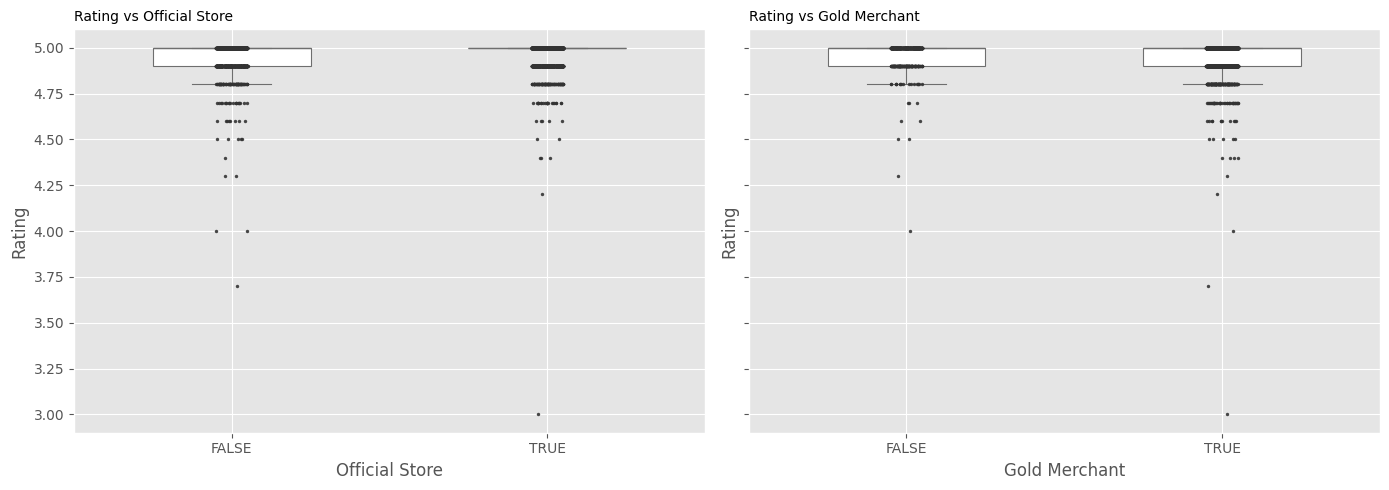

In [46]:
df_store_rating = (
    df_new_explode[["product_id", "rating_average", "is_official", "gold_merchant"]]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

def to_flag(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    normalized = series.astype(str).str.strip().str.lower()
    return normalized.map({"1": 1, "0": 0, "true": 1, "false": 0, "yes": 1, "no": 0})

df_store_rating["rating_average"] = pd.to_numeric(df_store_rating["rating_average"], errors="coerce").clip(lower=0, upper=5)
df_store_rating["is_official"] = to_flag(df_store_rating["is_official"])
df_store_rating["gold_merchant"] = to_flag(df_store_rating["gold_merchant"])

plot_specs = [
    ("is_official", "Rating vs Official Store", "Official Store"),
    ("gold_merchant", "Rating vs Gold Merchant", "Gold Merchant"),
]

if df_store_rating["rating_average"].dropna().empty:
    print("Data rating produk tidak tersedia untuk divisualisasikan.")
else:
    rng = np.random.default_rng(42)
    with plt.style.context("ggplot"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

        for ax, (col, title, xlabel) in zip(axes, plot_specs):
            temp = df_store_rating[[col, "rating_average"]].dropna().copy()
            groups = [
                temp.loc[temp[col] == 0, "rating_average"].values,
                temp.loc[temp[col] == 1, "rating_average"].values,
            ]

            if not any(len(group) for group in groups):
                ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(title, loc="left", fontsize=10)
                ax.set_xlabel(xlabel)
                continue

            box = ax.boxplot(
                groups,
                positions=[0, 1],
                widths=0.5,
                patch_artist=True,
                showfliers=False,
                boxprops=dict(facecolor="white", edgecolor="#6e6e6e", linewidth=0.8),
                medianprops=dict(color="#6e6e6e", linewidth=1.0),
                whiskerprops=dict(color="#6e6e6e", linewidth=0.8),
                capprops=dict(color="#6e6e6e", linewidth=0.8),
            )

            for pos, values in enumerate(groups):
                if len(values) == 0:
                    continue
                jitter = rng.uniform(-0.05, 0.05, size=len(values))
                ax.scatter(
                    np.full(len(values), pos) + jitter,
                    values,
                    s=6,
                    color="#333333",
                    alpha=0.9,
                    linewidths=0,
                    zorder=3,
                )

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["FALSE", "TRUE"])
            ax.set_title(title, loc="left", fontsize=10)
            ax.set_xlabel(xlabel)
            ax.set_ylim(2.9, 5.1)
            ax.set_ylabel("Rating")

        plt.tight_layout()
        plt.show()


## Discount vs Rating

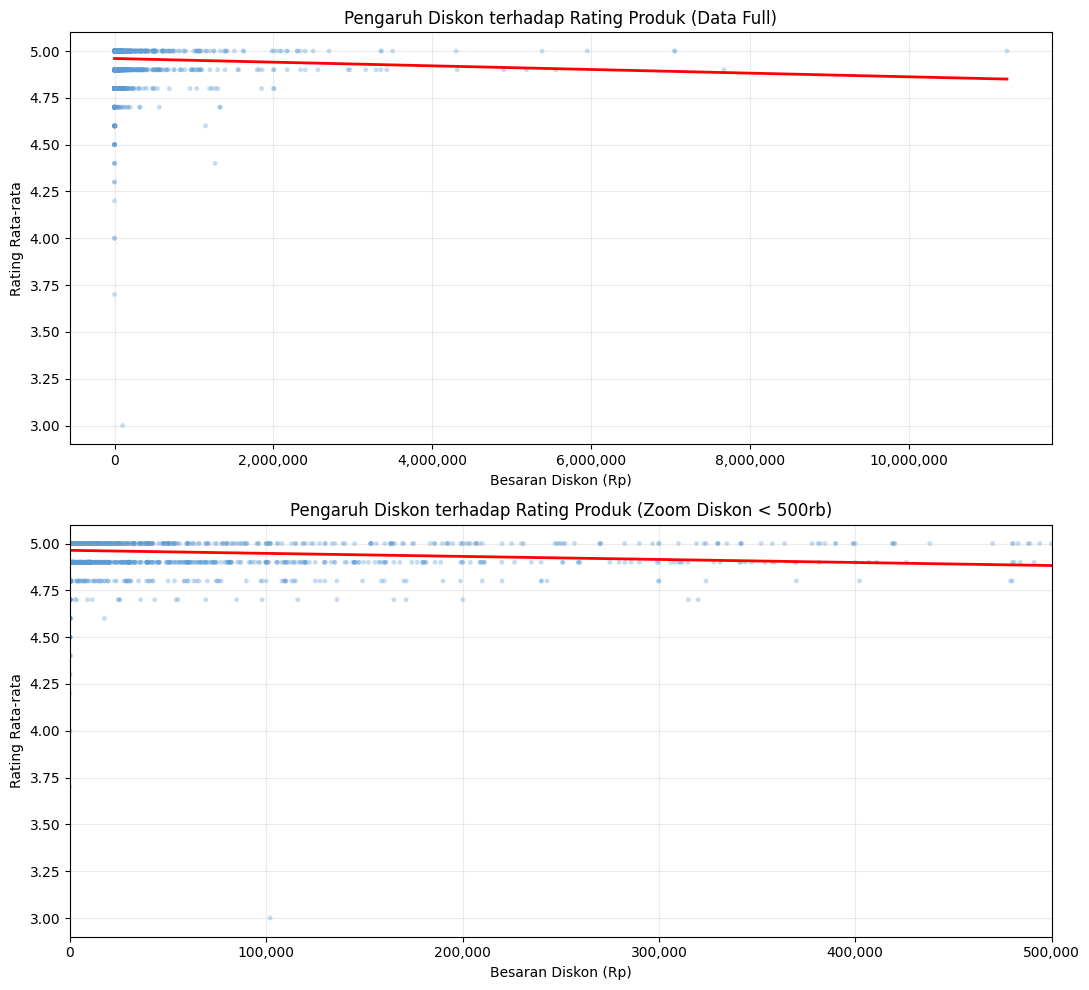

In [47]:
from matplotlib.ticker import FuncFormatter

df_discount_rating = (
    df_new_explode[["product_id", "price", "discounted_price", "rating_average"]]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

for col in ["price", "discounted_price", "rating_average"]:
    df_discount_rating[col] = pd.to_numeric(df_discount_rating[col], errors="coerce")

harga_jual = df_discount_rating["price"].fillna(df_discount_rating["discounted_price"])
harga_asli = df_discount_rating["discounted_price"].fillna(harga_jual)
df_discount_rating["discount_amount"] = (harga_asli - harga_jual).clip(lower=0)
df_discount_rating["rating_average"] = df_discount_rating["rating_average"].clip(lower=0, upper=5)
df_discount_rating = df_discount_rating.dropna(subset=["discount_amount", "rating_average"])

def add_trendline_rating(ax, x, y, color="red"):
    if len(x) < 2 or np.isclose(np.nanstd(x), 0):
        return
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ys = coef[0] * xs + coef[1]
    ax.plot(xs, ys, color=color, linewidth=2)

fmt = FuncFormatter(lambda val, pos: f"{int(val):,}" if np.isfinite(val) else "")

if df_discount_rating.empty:
    print("Data diskon dan rating produk tidak tersedia untuk divisualisasikan.")
else:
    zoom_x = 500000
    df_zoom = df_discount_rating[df_discount_rating["discount_amount"] <= zoom_x].copy()

    fig, axes = plt.subplots(2, 1, figsize=(11, 10))

    axes[0].scatter(
        df_discount_rating["discount_amount"],
        df_discount_rating["rating_average"],
        s=12,
        alpha=0.35,
        color="#5b9bd5",
        edgecolors="none",
    )
    add_trendline_rating(
        axes[0],
        df_discount_rating["discount_amount"],
        df_discount_rating["rating_average"],
    )
    axes[0].set_title("Pengaruh Diskon terhadap Rating Produk (Data Full)")
    axes[0].set_xlabel("Besaran Diskon (Rp)")
    axes[0].set_ylabel("Rating Rata-rata")
    axes[0].grid(alpha=0.25)
    axes[0].xaxis.set_major_formatter(fmt)

    axes[1].scatter(
        df_zoom["discount_amount"],
        df_zoom["rating_average"],
        s=12,
        alpha=0.35,
        color="#5b9bd5",
        edgecolors="none",
    )
    add_trendline_rating(
        axes[1],
        df_zoom["discount_amount"],
        df_zoom["rating_average"],
    )
    axes[1].set_title("Pengaruh Diskon terhadap Rating Produk (Zoom Diskon < 500rb)")
    axes[1].set_xlabel("Besaran Diskon (Rp)")
    axes[1].set_ylabel("Rating Rata-rata")
    axes[1].grid(alpha=0.25)
    axes[1].xaxis.set_major_formatter(fmt)
    axes[1].set_xlim(0, zoom_x)

    plt.tight_layout()
    plt.show()


## Discount vs Sales

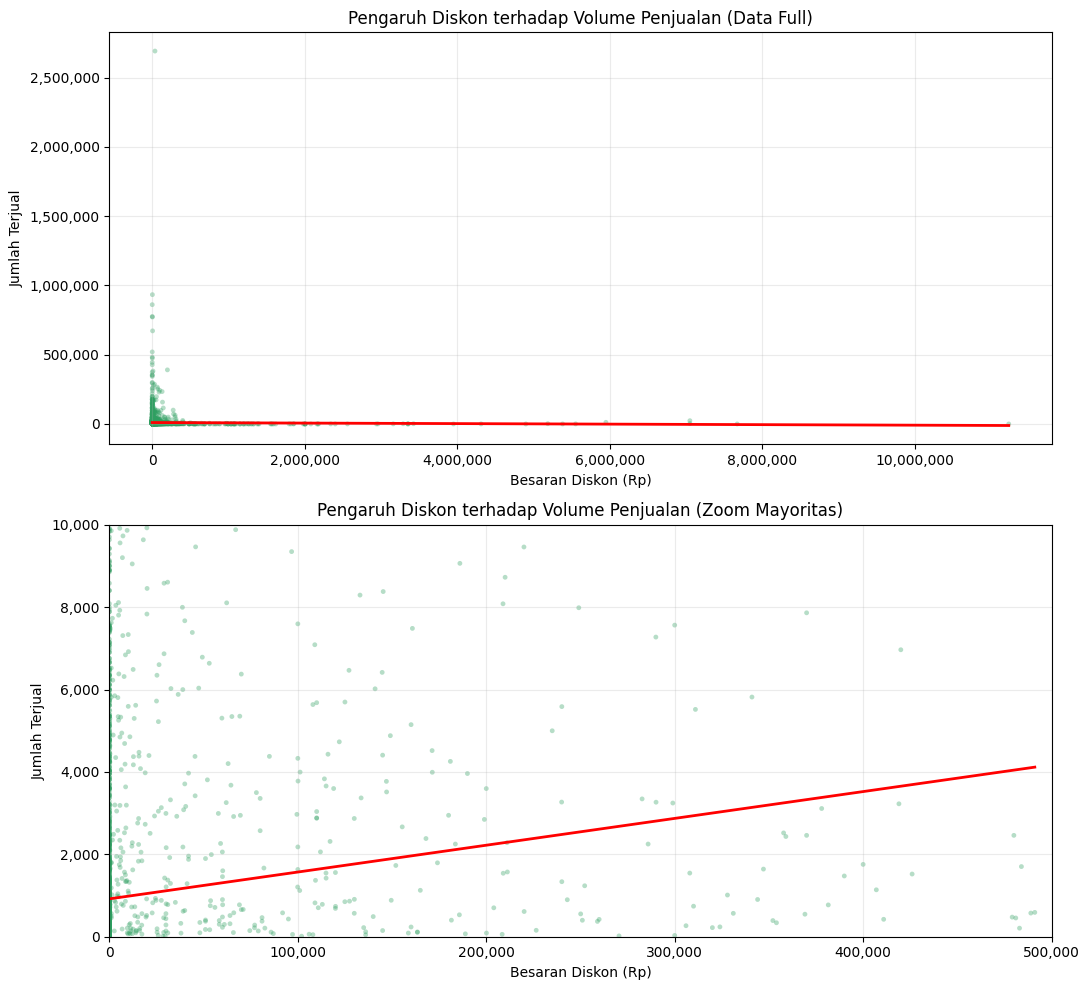

In [48]:
df_discount_sales = (
    df_new_explode[["product_id", "price", "discounted_price", "count_sold"]]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

for col in ["price", "discounted_price", "count_sold"]:
    df_discount_sales[col] = pd.to_numeric(df_discount_sales[col], errors="coerce")

harga_jual = df_discount_sales["price"].fillna(df_discount_sales["discounted_price"])
harga_asli = df_discount_sales["discounted_price"].fillna(harga_jual)
df_discount_sales["discount_amount"] = (harga_asli - harga_jual).clip(lower=0)
df_discount_sales["count_sold"] = df_discount_sales["count_sold"].clip(lower=0)
df_discount_sales = df_discount_sales.dropna(subset=["discount_amount", "count_sold"])

def add_trendline(ax, x, y, color="red"):
    if len(x) < 2 or np.isclose(np.nanstd(x), 0):
        return
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ys = coef[0] * xs + coef[1]
    ax.plot(xs, ys, color=color, linewidth=2)

fmt = FuncFormatter(lambda val, pos: f"{int(val):,}" if np.isfinite(val) else "")

if df_discount_sales.empty:
    print("Data diskon dan jumlah terjual tidak tersedia untuk divisualisasikan.")
else:
    zoom_x = 500000
    zoom_y = 10000
    df_zoom = df_discount_sales[
        (df_discount_sales["discount_amount"] <= zoom_x)
        & (df_discount_sales["count_sold"] <= zoom_y)
    ].copy()

    fig, axes = plt.subplots(2, 1, figsize=(11, 10))

    axes[0].scatter(
        df_discount_sales["discount_amount"],
        df_discount_sales["count_sold"],
        s=12,
        alpha=0.35,
        color="#2e9f61",
        edgecolors="none",
    )
    add_trendline(axes[0], df_discount_sales["discount_amount"], df_discount_sales["count_sold"])
    axes[0].set_title("Pengaruh Diskon terhadap Volume Penjualan (Data Full)")
    axes[0].set_xlabel("Besaran Diskon (Rp)")
    axes[0].set_ylabel("Jumlah Terjual")
    axes[0].grid(alpha=0.25)
    axes[0].xaxis.set_major_formatter(fmt)
    axes[0].yaxis.set_major_formatter(fmt)

    axes[1].scatter(
        df_zoom["discount_amount"],
        df_zoom["count_sold"],
        s=12,
        alpha=0.35,
        color="#2e9f61",
        edgecolors="none",
    )
    add_trendline(axes[1], df_zoom["discount_amount"], df_zoom["count_sold"])
    axes[1].set_title("Pengaruh Diskon terhadap Volume Penjualan (Zoom Mayoritas)")
    axes[1].set_xlabel("Besaran Diskon (Rp)")
    axes[1].set_ylabel("Jumlah Terjual")
    axes[1].grid(alpha=0.25)
    axes[1].xaxis.set_major_formatter(fmt)
    axes[1].yaxis.set_major_formatter(fmt)
    axes[1].set_xlim(0, zoom_x)
    axes[1].set_ylim(0, 10000)

    plt.tight_layout()
    plt.show()


## Keluhan Berdasarkan `bad_rating_reason`

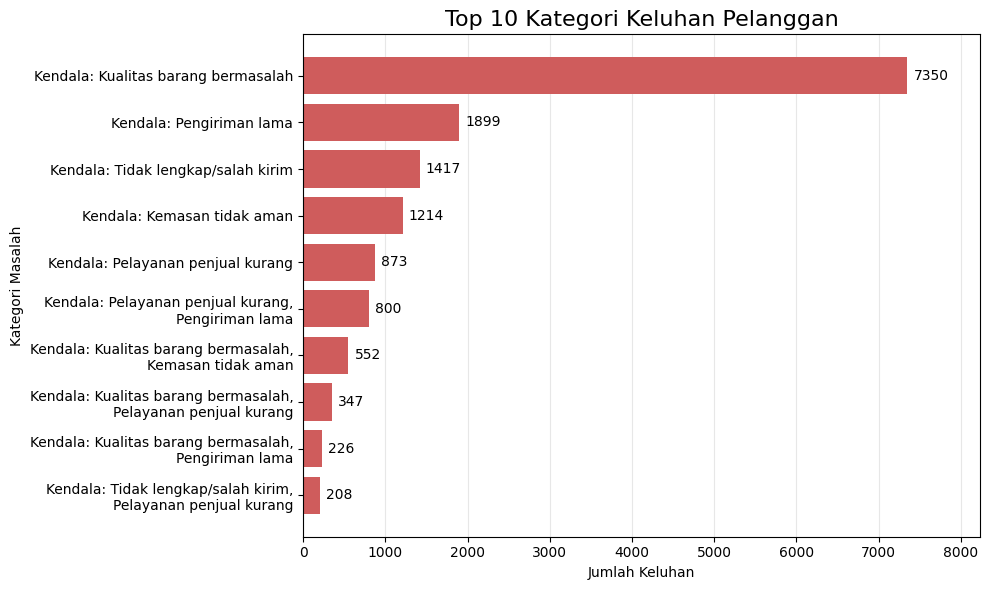

In [49]:
import textwrap

keluhan = (
    df_new_explode["bad_rating_reason"]
    .fillna("")
    .astype(str)
    .str.strip()
)
keluhan = keluhan[keluhan.ne("")]

top_keluhan = keluhan.value_counts().head(10).sort_values(ascending=True)

if top_keluhan.empty:
    print("Tidak ada data `bad_rating_reason` yang bisa divisualisasikan.")
else:
    wrapped_labels = [textwrap.fill(label, width=38) for label in top_keluhan.index]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(wrapped_labels, top_keluhan.values, color="#cf5c5c")

    offset = max(top_keluhan.max() * 0.01, 10)
    for bar, value in zip(bars, top_keluhan.values):
        ax.text(
            bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value}",
            va="center",
            ha="left",
            fontsize=10,
        )

    ax.set_title("Top 10 Kategori Keluhan Pelanggan", fontsize=16)
    ax.set_xlabel("Jumlah Keluhan")
    ax.set_ylabel("Kategori Masalah")
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_xlim(0, top_keluhan.max() * 1.12)
    plt.tight_layout()
    plt.show()


## Faktor-faktor yang mempengaruhi banyaknya like pada review konsumen

Output utamanya adalah tabel faktor paling berpengaruh, tabel detail beberapa faktor penting, dan visualisasi perubahan `any_like_rate` serta `avg_like`.

In [50]:
df_like = df_new_explode.copy()

In [51]:
# fungsi-fungsi pembantu

def parse_review_time(value):
    '''format lagi ke format waktu, buat makesure aja'''
    if pd.isna(value):
        return pd.NaT
    if isinstance(value, pd.Timestamp):
        return value.tz_localize(None) if getattr(value, "tzinfo", None) else value
    text = str(value).strip().replace("'", "")
    if text == "":
        return pd.NaT
    try:
        num = float(text)
        if np.isfinite(num) and abs(num) > 10000:
            ts = pd.to_datetime(int(num), unit="s", utc=True)
            return ts.tz_convert("Asia/Jakarta").tz_localize(None)
    except Exception:
        pass
    return pd.to_datetime(text, errors="coerce")


def to_binary(series):
    '''format lagi ke numerik, buat makesure aja'''
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce").fillna(0).astype(int)
    mapped = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({"1": 1, "0": 0, "true": 1, "false": 0, "yes": 1, "no": 0})
    )
    return mapped.fillna(0).astype(int)


def summarize_numeric_factor(data, col, label, q=4):
    '''menyimpulkan data dengan faktor numrik'''
    temp = data[[col, "review_like", "any_like"]].dropna().copy()
    if temp.empty or temp[col].nunique() < 2:
        return None, None
    bins = pd.qcut(temp[col], q=min(q, temp[col].nunique()), duplicates="drop")
    temp["group"] = bins.astype(str)
    detail = temp.groupby("group", observed=False).agg(
        any_like_rate=("any_like", "mean"),
        avg_like=("review_like", "mean"),
        n=("review_like", "size"),
    )
    if detail.shape[0] < 2:
        return None, None
    low = detail.iloc[0]
    high = detail.iloc[-1]
    if (high["any_like_rate"] > low["any_like_rate"]) and (high["avg_like"] > low["avg_like"]):
        direction = "cenderung positif"
    elif (high["any_like_rate"] < low["any_like_rate"]) and (high["avg_like"] < low["avg_like"]):
        direction = "cenderung negatif"
    else:
        direction = "campuran"
    row = {
        "faktor": label,
        "jenis": "numerik",
        "kelompok_rendah": detail.index[0],
        "kelompok_tinggi": detail.index[-1],
        "any_like_rate_rendah": low["any_like_rate"],
        "any_like_rate_tinggi": high["any_like_rate"],
        "delta_any_like_rate": high["any_like_rate"] - low["any_like_rate"],
        "avg_like_rendah": low["avg_like"],
        "avg_like_tinggi": high["avg_like"],
        "delta_avg_like": high["avg_like"] - low["avg_like"],
        "arah": direction,
        "n": detail["n"].sum(),
    }
    return row, detail


def summarize_binary_factor(data, col, label):
    '''menyimpulkan data dengan faktor yang binary'''
    temp = data[[col, "review_like", "any_like"]].dropna().copy()
    temp[col] = pd.to_numeric(temp[col], errors="coerce").fillna(0).astype(int)
    detail = temp.groupby(col, observed=False).agg(
        any_like_rate=("any_like", "mean"),
        avg_like=("review_like", "mean"),
        n=("review_like", "size"),
    )
    if not {0, 1}.issubset(set(detail.index.tolist())):
        return None, None
    low = detail.loc[0]
    high = detail.loc[1]
    if (high["any_like_rate"] > low["any_like_rate"]) and (high["avg_like"] > low["avg_like"]):
        direction = "cenderung positif"
    elif (high["any_like_rate"] < low["any_like_rate"]) and (high["avg_like"] < low["avg_like"]):
        direction = "cenderung negatif"
    else:
        direction = "campuran"
    row = {
        "faktor": label,
        "jenis": "biner",
        "kelompok_rendah": "0",
        "kelompok_tinggi": "1",
        "any_like_rate_rendah": low["any_like_rate"],
        "any_like_rate_tinggi": high["any_like_rate"],
        "delta_any_like_rate": high["any_like_rate"] - low["any_like_rate"],
        "avg_like_rendah": low["avg_like"],
        "avg_like_tinggi": high["avg_like"],
        "delta_avg_like": high["avg_like"] - low["avg_like"],
        "arah": direction,
        "n": detail["n"].sum(),
    }
    return row, detail

In [52]:
# cleaning lagi biar tidak error ketika review_like/review_time masih kotor, bakalan lama, tapi gpp lah
df_like["review_like"] = pd.to_numeric(df_like["review_like"], errors="coerce").fillna(0).clip(lower=0)
df_like["review_rating"] = pd.to_numeric(df_like["review_rating"], errors="coerce")
df_like["price"] = pd.to_numeric(df_like["price"], errors="coerce")
df_like["discounted_price"] = pd.to_numeric(df_like["discounted_price"], errors="coerce")
df_like["count_sold"] = pd.to_numeric(df_like["count_sold"], errors="coerce")
df_like["review_time"] = df_like["review_time"].apply(parse_review_time)
df_like["message"] = df_like["message"].fillna("").astype(str)
df_like["review_response"] = df_like["review_response"].fillna("").astype(str)
df_like["bad_rating_reason"] = df_like["bad_rating_reason"].fillna("").astype(str)

for col in ["is_official", "is_topads", "gold_merchant", "preorder"]:
    df_like[col] = to_binary(df_like[col])

if "category_1" not in df_like.columns:
    df_like["category_1"] = df_like["category"].astype(str).str.split("|").str[0]

In [53]:
# feature engineering
df_like["review_length_words"] = df_like["message"].str.split().str.len().fillna(0)
df_like["review_length_chars"] = df_like["message"].str.len()
df_like["has_response"] = (df_like["review_response"].str.strip() != "").astype(int)
df_like["has_bad_rating_reason"] = (df_like["bad_rating_reason"].str.strip() != "").astype(int)
max_review_time = df_like["review_time"].max()
df_like["review_age_days"] = (max_review_time - df_like["review_time"]).dt.days
df_like["review_age_days"] = df_like["review_age_days"].fillna(df_like["review_age_days"].median())
harga_jual = df_like["price"].fillna(df_like["discounted_price"])
harga_asli = df_like["discounted_price"].fillna(harga_jual)
df_like["discount_pct"] = np.where(
    harga_asli.gt(0),
    ((harga_asli - harga_jual) / harga_asli).clip(0, 1),
    0,
)
df_like["log_price"] = np.log1p(harga_jual.clip(lower=0))
df_like["log_count_sold"] = np.log1p(df_like["count_sold"].clip(lower=0))
df_like["any_like"] = (df_like["review_like"] > 0).astype(int)

In [54]:
factor_rows = []
factor_details = {}

numeric_factors = [
    ("review_rating", "Rating review"),
    ("review_length_words", "Panjang review (kata)"),
    ("review_age_days", "Umur review (hari)"),
    ("discount_pct", "Persentase diskon"),
    ("log_price", "Harga produk (log)"),
    ("log_count_sold", "Jumlah terjual (log)"),
]

binary_factors = [
    ("has_response", "Ada respons penjual"),
    ("has_bad_rating_reason", "Ada alasan bad rating"),
    ("is_official", "Official store"),
    ("is_topads", "TopAds"),
    ("gold_merchant", "Gold merchant"),
    ("preorder", "Produk preorder"),
]

for col, label in numeric_factors:
    row, detail = summarize_numeric_factor(df_like, col, label)
    if row is not None:
        factor_rows.append(row)
        factor_details[label] = detail

for col, label in binary_factors:
    row, detail = summarize_binary_factor(df_like, col, label)
    if row is not None:
        factor_rows.append(row)
        factor_details[label] = detail

top_categories = df_like["category_1"].fillna("Tidak diketahui").astype(str).value_counts().head(10).index
category_detail = (
    df_like.loc[df_like["category_1"].isin(top_categories)]
    .groupby("category_1", observed=False)
    .agg(
        any_like_rate=("any_like", "mean"),
        avg_like=("review_like", "mean"),
        n=("review_like", "size"),
    )
    .sort_values(["any_like_rate", "avg_like"], ascending=False)
)

if category_detail.shape[0] >= 2:
    best = category_detail.iloc[0]
    worst = category_detail.iloc[-1]
    if (best["any_like_rate"] > worst["any_like_rate"]) and (best["avg_like"] > worst["avg_like"]):
        direction = "cenderung positif"
    elif (best["any_like_rate"] < worst["any_like_rate"]) and (best["avg_like"] < worst["avg_like"]):
        direction = "cenderung negatif"
    else:
        direction = "campuran"
    factor_rows.append({
        "faktor": "Kategori produk (Top 10)",
        "jenis": "kategori",
        "kelompok_rendah": str(category_detail.index[-1]),
        "kelompok_tinggi": str(category_detail.index[0]),
        "any_like_rate_rendah": worst["any_like_rate"],
        "any_like_rate_tinggi": best["any_like_rate"],
        "delta_any_like_rate": best["any_like_rate"] - worst["any_like_rate"],
        "avg_like_rendah": worst["avg_like"],
        "avg_like_tinggi": best["avg_like"],
        "delta_avg_like": best["avg_like"] - worst["avg_like"],
        "arah": direction,
        "n": category_detail["n"].sum(),
    })
    factor_details["Kategori produk (Top 10)"] = category_detail

factor_summary = pd.DataFrame(factor_rows)
overall_avg_like = max(df_like["review_like"].mean(), 1e-9)
factor_summary["delta_any_like_pp"] = factor_summary["delta_any_like_rate"] * 100
factor_summary["delta_avg_like_rel"] = factor_summary["delta_avg_like"] / overall_avg_like
factor_summary["importance_score"] = (
    factor_summary["delta_any_like_pp"].abs().rank(pct=True)
    + factor_summary["delta_avg_like_rel"].abs().rank(pct=True)
) / 2
factor_summary = factor_summary.sort_values("importance_score", ascending=False)

cols_to_show = [
    "faktor", "jenis", "arah", "kelompok_rendah", "kelompok_tinggi",
    "delta_any_like_pp", "delta_avg_like", "importance_score", "n"
]
print("Ringkasan faktor yang paling berkaitan dengan banyaknya like:")
display(factor_summary[cols_to_show].head(10).style.format({
    "delta_any_like_pp": "{:.2f}",
    "delta_avg_like": "{:.4f}",
    "importance_score": "{:.2f}",
    "n": "{:.0f}",
}))

Ringkasan faktor yang paling berkaitan dengan banyaknya like:


,faktor,jenis,arah,kelompok_rendah,kelompok_tinggi,delta_any_like_pp,delta_avg_like,importance_score,n
6,Ada alasan bad rating,biner,cenderung positif,0,1,22.74,0.7147,1.00,1228885
9,Kategori produk (Top 10),kategori,cenderung positif,makanan_minuman,handphone_tablet,15.22,0.4459,0.90,965334
0,Panjang review (kata),numerik,cenderung positif,"(-0.001, 2.0]","(5.0, 10.0]",4.04,0.0763,0.75,1228885
4,Jumlah terjual (log),numerik,cenderung negatif,"(0.692, 9.539]","(9.539, 10.594]",-3.18,-0.0793,0.70,1138780
5,Ada respons penjual,biner,cenderung positif,0,1,3.80,0.0619,0.65,1228885
7,Official store,biner,cenderung positif,0,1,1.85,0.0532,0.50,1228885
2,Persentase diskon,numerik,cenderung negatif,"(-0.001, 0.14]","(0.38, 0.877]",-1.31,-0.0303,0.40,1228885
3,Harga produk (log),numerik,cenderung negatif,"(10.232, 11.015]","(5.619, 10.232]",-1.15,-0.0182,0.30,1228885
8,Gold merchant,biner,campuran,0,1,-0.83,0.0081,0.20,1228885
1,Umur review (hari),numerik,campuran,"(-0.001, 215.0]","(602.0, 1322.0]",0.57,-0.0007,0.10,1228885


In [55]:
print("\nDetail beberapa faktor utama:")
for label in [
    "Rating review",
    "Panjang review (kata)",
    "Ada respons penjual",
    "Umur review (hari)",
    "Kategori produk (Top 10)",
]:
    if label in factor_details:
        print(f"\n{label}")
        display(factor_details[label].style.format({
            "any_like_rate": "{:.4f}",
            "avg_like": "{:.4f}",
            "n": "{:.0f}",
        }))


Detail beberapa faktor utama:

Panjang review (kata)


,any_like_rate,avg_like,n
group,,,
"(-0.001, 2.0]",0.0201,0.0308,389128
"(10.0, 14784.0]",0.1234,0.3075,272031
"(2.0, 5.0]",0.0327,0.0513,259584
"(5.0, 10.0]",0.0606,0.1071,308142



Ada respons penjual


,any_like_rate,avg_like,n
has_response,,,
0,0.0308,0.0749,423021
1,0.0689,0.1368,805864



Umur review (hari)


,any_like_rate,avg_like,n
group,,,
"(-0.001, 215.0]",0.0473,0.0933,307605
"(1322.0, 3899.0]",0.0460,0.1134,306731
"(215.0, 602.0]",0.0768,0.1627,307331
"(602.0, 1322.0]",0.0530,0.0926,307218



Kategori produk (Top 10)


,any_like_rate,avg_like,n
category_1,,,
handphone_tablet,0.1823,0.4990,61121
elektronik,0.0687,0.1449,120342
rumah_tangga,0.0672,0.1387,118131
olahraga,0.0566,0.1035,112090
perawatan_tubuh,0.0434,0.0811,171741
kesehatan,0.0406,0.0783,65054
komputer_laptop,0.0394,0.0975,65704
kecantikan,0.0338,0.0503,112491
office_stationery,0.0314,0.0454,68774


In [56]:
df_new_explode['is_official'].unique()

array([False,  True])

<Axes: title={'center': 'Top 5 Faktor Ulasan Mendapatkan Like'}, xlabel='Selisih any_like_rate (poin persentase)', ylabel='faktor'>

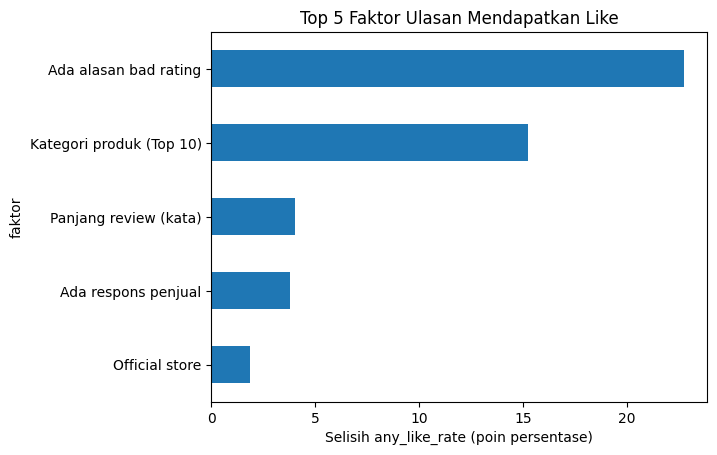

In [57]:
factor_summary.set_index('faktor')[
    'delta_any_like_pp'].sort_values(ascending=False).head(5).sort_values().plot(
        kind='barh',
        title='Top 5 Faktor Ulasan Mendapatkan Like',
        xlabel='Selisih any_like_rate (poin persentase)',
        )

<Axes: ylabel='faktor'>

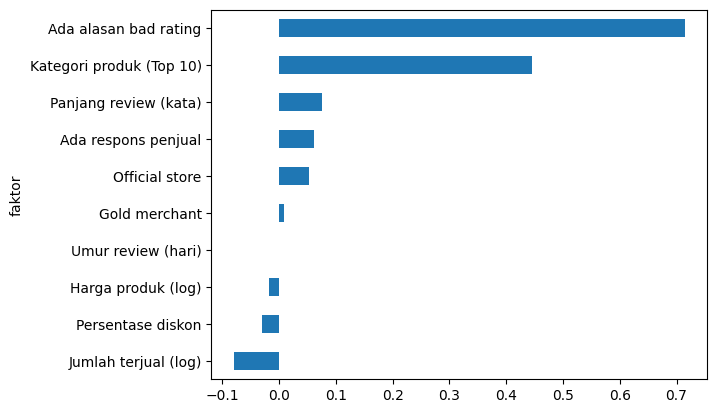

In [58]:
factor_summary.set_index('faktor')['delta_avg_like'].sort_values().plot(kind='barh')

# `Not Used`

In [ ]:
top_plot = factor_summary.head(8).iloc[::-1].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_plot["faktor"], top_plot["delta_any_like_pp"], color="#2a9d8f")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Perubahan peluang review mendapat like")
axes[0].set_xlabel("Selisih any_like_rate (poin persentase)")

axes[1].barh(top_plot["faktor"], top_plot["delta_avg_like"], color="#e76f51")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Perubahan rata-rata jumlah like")
axes[1].set_xlabel("Selisih avg_like")

plt.suptitle("Faktor-faktor yang mempengaruhi banyaknya like pada review konsumen")
plt.tight_layout()
plt.show()

print("\nKesimpulan cepat:")
for _, row in factor_summary.head(5).iterrows():
    print(
        f"- {row['faktor']}: {row['arah']} | {row['kelompok_tinggi']} vs {row['kelompok_rendah']} | "
        f"delta any_like_rate = {row['delta_any_like_pp']:.2f} p.p. | delta avg_like = {row['delta_avg_like']:.4f}"
    )
